Shape: (2128, 527)
Features: (2128, 524), Labels: 2128
Data split: Train=(1489, 524), Test=(639, 524)
All_Features: CV AUC = 0.8122 ± 0.0149
LASSO: CV AUC = 0.8189 ± 0.0188
Best_First_Search: CV AUC = 0.8131 ± 0.0115
Random_Feature_Selection: CV AUC = 0.8058 ± 0.0163

Best Feature Selection Method: LASSO
Best CV AUC: 0.8189

Training models using LASSO on training data...

Performing GridSearchCV for Random_Forest...
Fitting 5 folds for each of 72 candidates, totalling 360 fits
Random_Forest: Best CV AUC = 0.9569
Best params: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 4, 'model__min_samples_split': 5, 'model__n_estimators': 600}

Performing GridSearchCV for XGBoost...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
XGBoost: Best CV AUC = 0.9693
Best params: {'model__colsample_bytree': 0.7, 'model__learning_rate': 0.03, 'model__max_depth': 7, 'model__n_estimators': 600, 'model__subsample': 0.75}

Performing GridSearchCV for SVM...

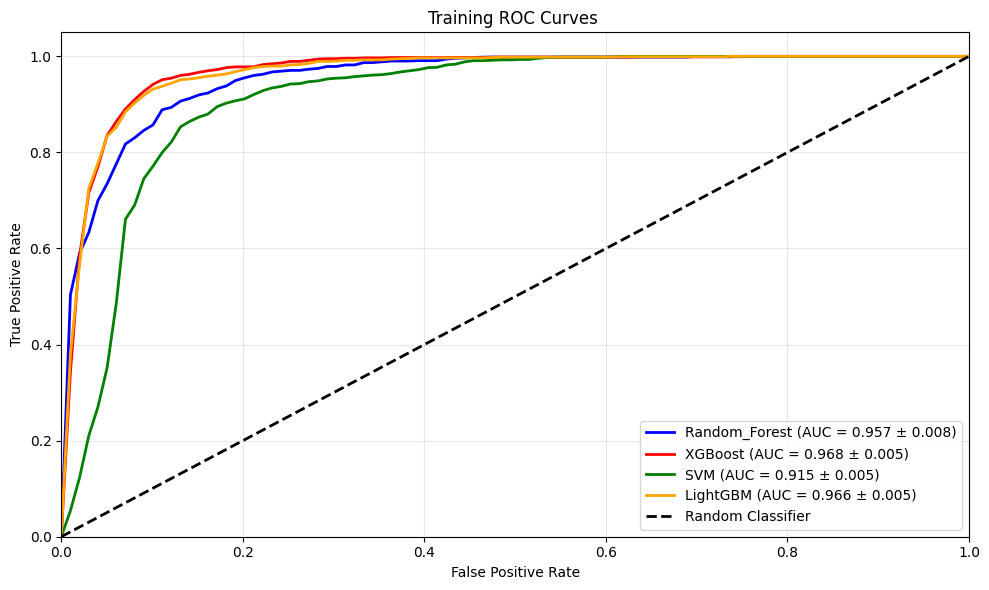


Calculating SHAP importance for XGBoost...
Generating SHAP Summary Plot...


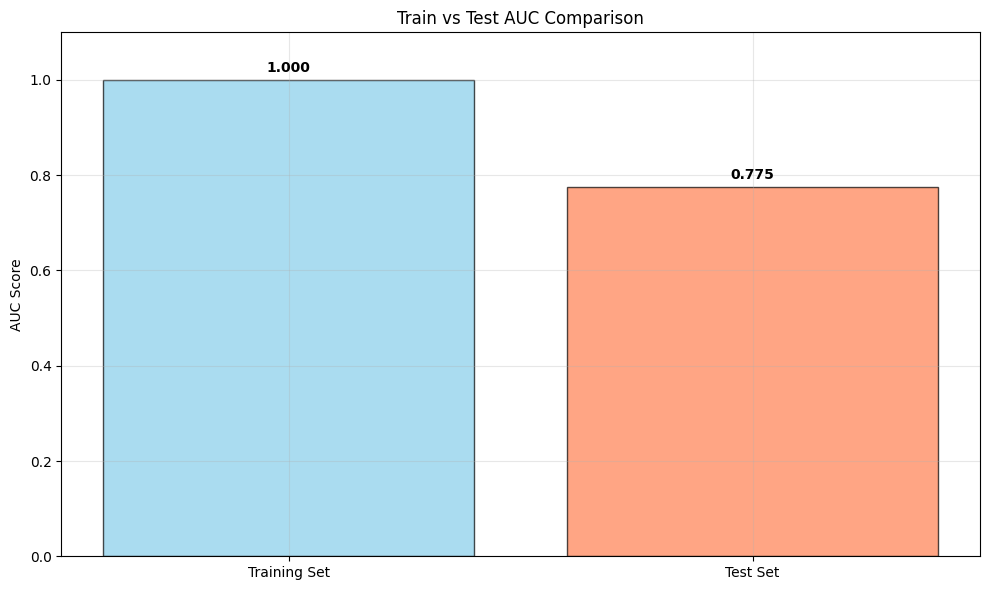

Train AUC: 1.0000
Test AUC:  0.7752

Generating AUC Curves...


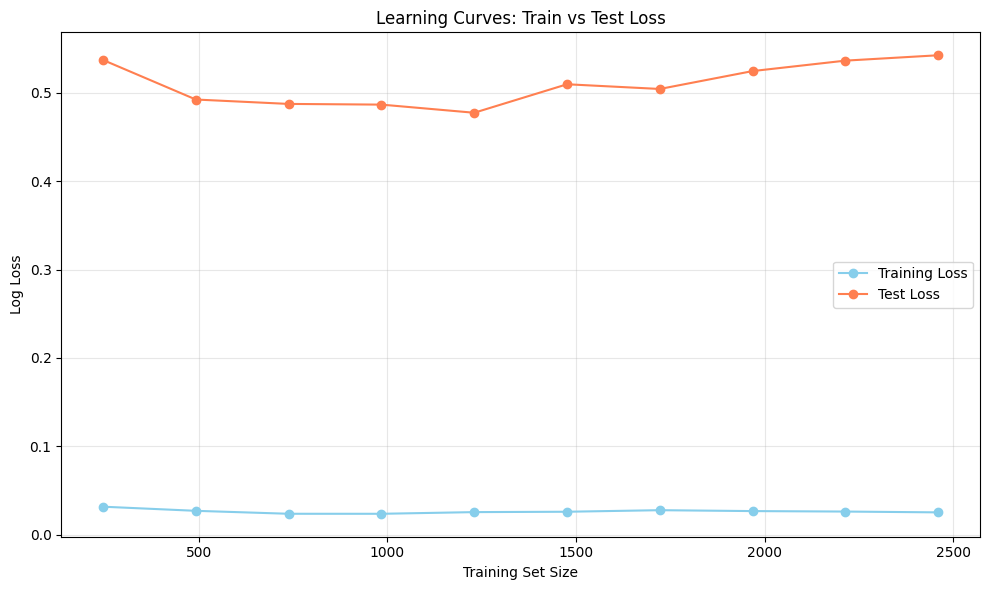


=== Ranking genes by ASD risk probability ===

=== Train set Evaluation ===
Accuracy:     1.0000
Precision:    1.0000
Recall:       1.0000
F1-Score:     1.0000

Top 20 High-Risk ASD Genes:
   Gene  ASD_Risk_Probability  Risk_Rank  True_Label
   POGZ              0.995091          1           1
   MLL3              0.988985          2           1
CNTNAP5              0.986467          3           1
  ACACA              0.981778          4           0
  KDM5C              0.981305          5           1
  MYT1L              0.980085          6           1
WHSC1L1              0.979685          7           0
 CCDC64              0.978294          8           1
 MED13L              0.975559          9           1
 SPTBN2              0.971554         10           0
  ASH1L              0.971144         11           1
 TNRC6B              0.970821         12           1
  ABCA3              0.966270         13           0
   LYST              0.964906         14           0
  BIRC6        

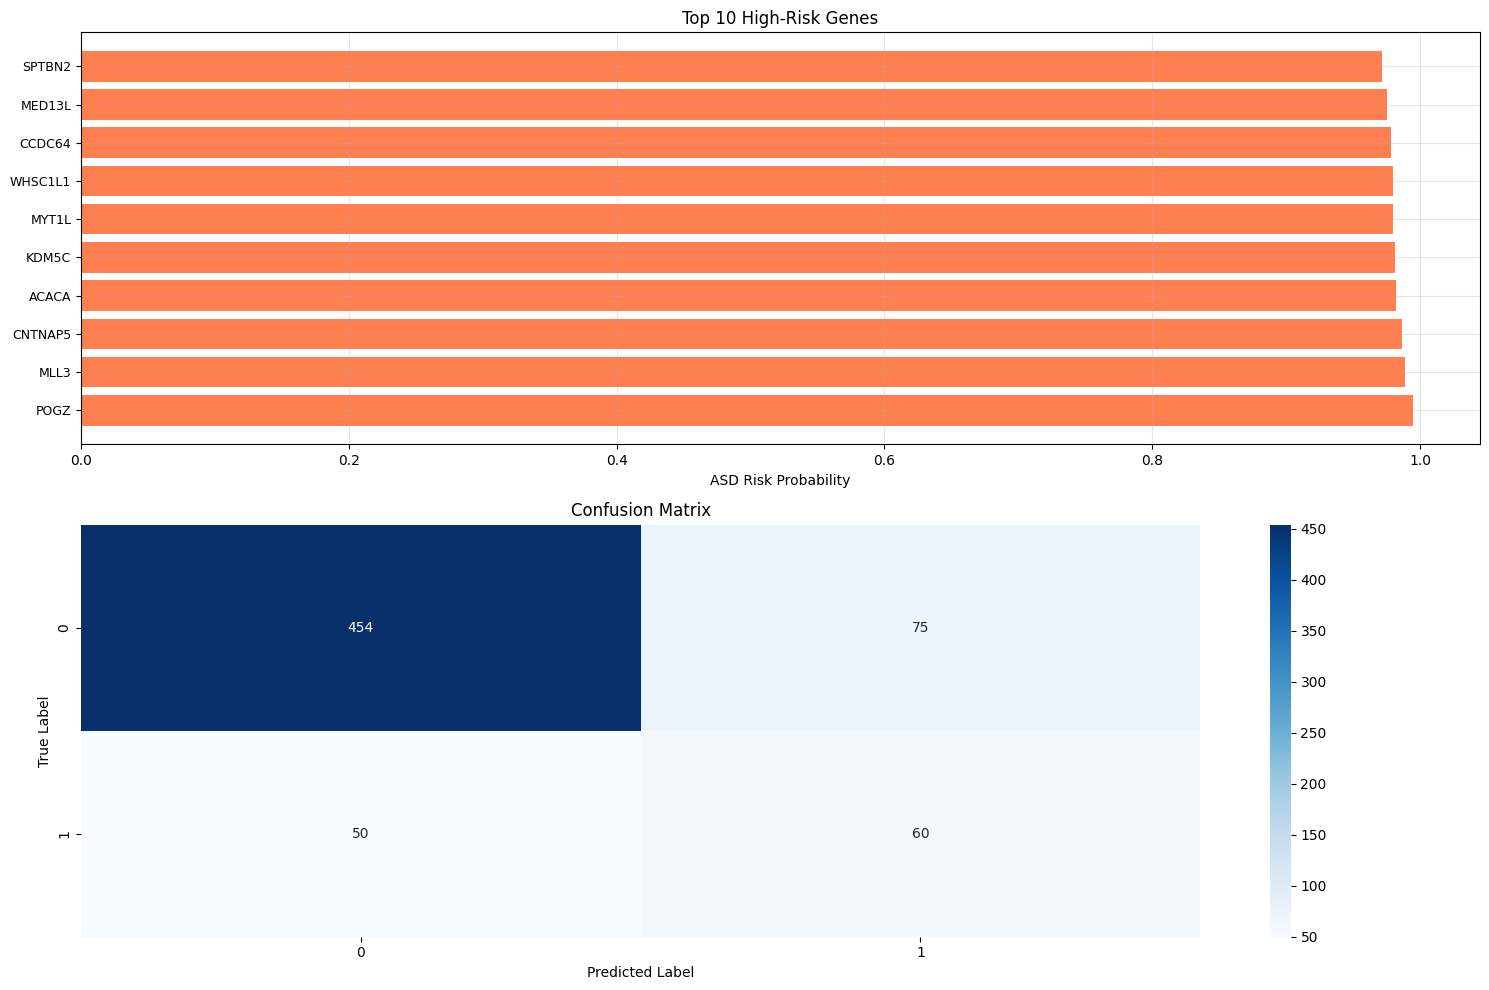


=== SUMMARY ===
Best Feature Selection: LASSO
Best Model: XGBoost
Best Model Params: {'model__colsample_bytree': 0.7, 'model__learning_rate': 0.03, 'model__max_depth': 7, 'model__n_estimators': 600, 'model__subsample': 0.75}


In [5]:
import pandas as pd
import numpy as np
import shap
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, roc_curve, accuracy_score,
    precision_score, recall_score, f1_score, confusion_matrix, log_loss
)
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel, RFE
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')


class ASDGeneticsResearch:
    def __init__(self, data_path):
        self.data_path = data_path
        self.data = None
        self.X = None
        self.y = None
        self.gene_names = None
        self.feature_cols = None
        self.scaler = StandardScaler()
        self.best_model = None
        self.best_model_name = None
        self.best_model_params = None
        self.feature_selection_results = {}

        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.gene_train = None
        self.gene_test = None

    def load_data_simple(self):
        self.data = pd.read_csv(self.data_path)
        print(f"Shape: {self.data.shape}")

        self.gene_names = self.data['Gene'].values
        feature_cols = [col for col in self.data.columns
                        if col not in ['Gene', 'Ensembl ID', 'Gene Type']]
        self.feature_cols = feature_cols
        self.X = self.data[feature_cols].values
        self.y = self.data['Gene Type'].values.astype(int)

        print(f"Features: {self.X.shape}, Labels: {len(self.y)}")
        return self.X, self.y, self.gene_names

    def compare_feature_selection_methods_cv(self, X, y):
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        test_model = RandomForestClassifier(n_estimators=100, random_state=42)

        methods = {
            'All_Features': None,
            'LASSO': LogisticRegression(
                penalty='l1', solver='liblinear',
                C=0.1, random_state=42, max_iter=1000),
            'Best_First_Search': RandomForestClassifier(
                n_estimators=10, random_state=42),
            'Random_Feature_Selection': None
        }

        results = {}
        for method_name, selector_model in methods.items():
            cv_scores = []
            for train_idx, val_idx in cv.split(X, y):
                X_train, X_val = X[train_idx], X[val_idx]
                y_train, y_val = y[train_idx], y[val_idx]

                scaler = StandardScaler()
                X_train_scaled = scaler.fit_transform(X_train)
                X_val_scaled = scaler.transform(X_val)

                min_samples = min(np.bincount(y_train))
                k_neighbors = max(1, min(3, min_samples - 1))
                smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
                X_train_balanced, y_train_balanced = smote.fit_resample(
                    X_train_scaled, y_train
                )

                if method_name == 'All_Features':
                    X_train_selected = X_train_balanced
                    X_val_selected = X_val_scaled
                elif method_name == 'LASSO':
                    selector = SelectFromModel(selector_model)
                    selector.fit(X_train_balanced, y_train_balanced)
                    X_train_selected = selector.transform(X_train_balanced)
                    X_val_selected = selector.transform(X_val_scaled)
                elif method_name == 'Best_First_Search':
                    n_features = min(20, X_train_balanced.shape[1])
                    selector = RFE(
                        selector_model,
                        n_features_to_select=n_features,
                        step=1
                    )
                    selector.fit(X_train_balanced, y_train_balanced)
                    X_train_selected = selector.transform(X_train_balanced)
                    X_val_selected = selector.transform(X_val_scaled)
                elif method_name == 'Random_Feature_Selection':
                    k_features = min(15, X_train_balanced.shape[1])
                    np.random.seed(42)
                    selected_indices = np.random.choice(
                        X_train_balanced.shape[1],
                        k_features,
                        replace=False
                    )
                    X_train_selected = X_train_balanced[:, selected_indices]
                    X_val_selected = X_val_scaled[:, selected_indices]

                test_model.fit(X_train_selected, y_train_balanced)
                y_pred_proba = test_model.predict_proba(X_val_selected)[:, 1]
                auc_score = roc_auc_score(y_val, y_pred_proba)
                cv_scores.append(auc_score)

            results[method_name] = {
                'cv_auc_mean': np.mean(cv_scores),
                'cv_auc_std': np.std(cv_scores),
                'cv_scores': cv_scores
            }
            print(f"{method_name}: CV AUC = {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")

        best_method = max(results.keys(), key=lambda k: results[k]['cv_auc_mean'])
        print(f"\nBest Feature Selection Method: {best_method}")
        print(f"Best CV AUC: {results[best_method]['cv_auc_mean']:.4f}")

        return best_method, results

    def grid_search_model(self, model, param_grid, X_train, y_train, cv=5):
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('smote', SMOTE(random_state=42)),
            ('model', model)
        ])

        grid_search = GridSearchCV(
            pipeline, param_grid,
            cv=StratifiedKFold(n_splits=cv, shuffle=True, random_state=42),
            scoring='roc_auc',
            n_jobs=-1,
            verbose=1
        )

        grid_search.fit(X_train, y_train)
        return grid_search.best_estimator_, grid_search.best_params_, grid_search.best_score_

    def train_final_model(self, X, y, best_method):
        print(f"\nTraining models using {best_method} on training data...")

        X_scaled = self.scaler.fit_transform(X)
        min_samples = min(np.bincount(y))
        k_neighbors = max(1, min(3, min_samples - 1))
        smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
        X_balanced, y_balanced = smote.fit_resample(X_scaled, y)

        if best_method == 'All_Features':
            X_final = X_balanced
        elif best_method == 'LASSO':
            selector = SelectFromModel(LogisticRegression(
                penalty='l1', solver='liblinear',
                C=0.1, random_state=42, max_iter=1000))
            selector.fit(X_balanced, y_balanced)
            X_final = selector.transform(X_balanced)
        elif best_method == 'Best_First_Search':
            n_features = min(20, X_balanced.shape[1])
            selector = RFE(RandomForestClassifier(
                n_estimators=50, random_state=42),
                n_features_to_select=n_features,
                step=1)
            selector.fit(X_balanced, y_balanced)
            X_final = selector.transform(X_balanced)
        elif best_method == 'Random_Feature_Selection':
            k_features = min(15, X_balanced.shape[1])
            np.random.seed(42)
            selected_indices = np.random.choice(
                X_balanced.shape[1], k_features, replace=False)
            X_final = X_balanced[:, selected_indices]
        else:
            X_final = X_balanced

        models_param_grids = {
            'Random_Forest': {
                'model': RandomForestClassifier(random_state=42),
                'param_grid': {
                    'model__n_estimators': [200, 400, 600],
                    'model__max_depth': [10, 15, None],
                    'model__min_samples_split': [5, 8],
                    'model__min_samples_leaf': [4, 6],
                    'model__max_features': ['sqrt', 'log2']
                }
            },
            'XGBoost': {
                'model': xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
                'param_grid': {
                    'model__n_estimators': [200, 400, 600],
                    'model__max_depth': [4, 5, 7],
                    'model__learning_rate': [0.01, 0.02, 0.03],
                    'model__subsample': [0.7, 0.75],
                    'model__colsample_bytree': [0.7, 0.75]
                }
            },
            'SVM': {
                'model': SVC(probability=True, random_state=42),
                'param_grid': {
                    'model__C': [1, 3, 5],
                    'model__gamma': ['scale', 0.01, 0.001],
                    'model__kernel': ['rbf', 'poly']
                }
            },
            'LightGBM': {
                'model': lgb.LGBMClassifier(random_state=42, verbose=-1),
                'param_grid': {
                    'model__n_estimators': [200, 400, 600],
                    'model__max_depth': [4, 5, 7],
                    'model__learning_rate': [0.01, 0.02, 0.03],
                    'model__num_leaves': [20, 31]
                }
            }
        }

        cv_results = {}
        for name, config in models_param_grids.items():
            print(f"\nPerforming GridSearchCV for {name}...")
            best_model, best_params, best_cv_score = self.grid_search_model(
                config['model'], config['param_grid'], X_final, y_balanced
            )
            cv_results[name] = {
                'cv_auc_mean': best_cv_score,
                'cv_auc_std': 0.0,
                'model': best_model,
                'best_params': best_params
            }
            print(f"{name}: Best CV AUC = {best_cv_score:.4f}")
            print(f"Best params: {best_params}")

        best_model_name = max(cv_results.keys(), key=lambda k: cv_results[k]['cv_auc_mean'])
        self.best_model = cv_results[best_model_name]['model']
        self.best_model_name = best_model_name
        self.best_model_params = cv_results[best_model_name]['best_params']

        print(f"\nBest Model: {best_model_name}")
        print(f"Best CV AUC: {cv_results[best_model_name]['cv_auc_mean']:.4f}")
        print(f"Best params: {self.best_model_params}")

        return cv_results

    def get_shap_importance(self, X, y, best_method):
        print(f"\nCalculating SHAP importance for {self.best_model_name}...")

        X_scaled = self.scaler.transform(X)
        min_samples = min(np.bincount(y))
        k_neighbors = max(1, min(3, min_samples - 1))
        smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
        X_balanced, y_balanced = smote.fit_resample(X_scaled, y)

        if best_method == 'All_Features':
            X_final = X_balanced
            selected_features = self.feature_cols
        elif best_method == 'LASSO':
            selector = SelectFromModel(LogisticRegression(
                penalty='l1', solver='liblinear',
                C=0.1, random_state=42, max_iter=1000))
            selector.fit(X_balanced, y_balanced)
            feature_mask = selector.get_support()
            selected_features = [self.feature_cols[i] for i, m in enumerate(feature_mask) if m]
            X_final = selector.transform(X_balanced)
        elif best_method == 'Best_First_Search':
            n_features = min(20, X_balanced.shape[1])
            selector = RFE(RandomForestClassifier(
                n_estimators=50, random_state=42),
                n_features_to_select=n_features,
                step=1)
            selector.fit(X_balanced, y_balanced)
            feature_mask = selector.get_support()
            selected_features = [self.feature_cols[i] for i, m in enumerate(feature_mask) if m]
            X_final = selector.transform(X_balanced)
        elif best_method == 'Random_Feature_Selection':
            k_features = min(15, X_balanced.shape[1])
            np.random.seed(42)
            selected_indices = np.random.choice(
                X_balanced.shape[1], k_features, replace=False)
            selected_features = [self.feature_cols[i] for i in selected_indices]
            X_final = X_balanced[:, selected_indices]
        else:
            X_final = X_balanced
            selected_features = self.feature_cols

        model = self.best_model.named_steps['model']
        model.fit(X_final, y_balanced)

        print("Generating SHAP Summary Plot...")

        if isinstance(model, (RandomForestClassifier, xgb.XGBClassifier, lgb.LGBMClassifier)):
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_final)

            if isinstance(shap_values, list):
                if len(shap_values) == 2:
                    shap_vals = shap_values[1]
                else:
                    shap_vals = shap_values[0]
            else:
                shap_vals = shap_values
        else:
            background_size = min(100, X_final.shape[0])
            background = shap.sample(X_final, background_size, random_state=42) if X_final.shape[0] > 100 else X_final
            explainer = shap.Explainer(model, background)
            shap_output = explainer(X_final)
            shap_vals = shap_output.values
            if shap_vals.ndim == 3:
                shap_vals = shap_vals[:, :, 1]

        X_final_df = pd.DataFrame(X_final, columns=selected_features)

        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_vals, X_final_df, show=False)
        plt.title(f'SHAP Summary Plot for ASD Gene Expression Prediction\n({self.best_model_name})', fontsize=14, pad=20)
        plt.tight_layout()
        plt.savefig('shap_summary_plot.png', dpi=300, bbox_inches='tight', facecolor='white')
        plt.close()

        importance = np.abs(shap_vals).mean(axis=0)
        shap_df = pd.DataFrame({
            'Feature': selected_features,
            'SHAP_Importance': importance
        }).sort_values('SHAP_Importance', ascending=False).reset_index(drop=True)

        shap_df.to_csv('shap_feature_importance.csv', index=False)

        plt.figure(figsize=(10, 6))
        top_n = min(20, len(shap_df))
        plt.barh(
            shap_df['Feature'].head(top_n)[::-1],
            shap_df['SHAP_Importance'].head(top_n)[::-1],
            color='steelblue'
        )
        plt.xlabel('Mean |SHAP value|')
        plt.title('Top SHAP Feature Importance')
        plt.tight_layout()
        plt.savefig('shap_feature_importance.png', dpi=300, bbox_inches='tight')
        plt.close()

        return shap_df

    def plot_train_test_auc_comparison(self):
        X_train_scaled = self.scaler.transform(self.X_train)
        min_samples = min(np.bincount(self.y_train))
        k_neighbors = max(1, min(3, min_samples - 1))
        smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
        X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, self.y_train)

        if self.feature_selection_results:
            best_method = max(
                self.feature_selection_results.keys(),
                key=lambda k: self.feature_selection_results[k]['cv_auc_mean']
            )
        else:
            best_method = 'All_Features'

        if best_method != 'All_Features':
            if best_method == 'LASSO':
                selector = SelectFromModel(LogisticRegression(
                    penalty='l1', solver='liblinear', C=0.1, random_state=42, max_iter=1000))
                selector.fit(X_train_bal, y_train_bal)
                X_train_final = selector.transform(X_train_bal)
                X_test_final = selector.transform(self.scaler.transform(self.X_test))
            elif best_method == 'Best_First_Search':
                n_features = min(20, X_train_bal.shape[1])
                selector = RFE(
                    RandomForestClassifier(n_estimators=50, random_state=42),
                    n_features_to_select=n_features, step=1)
                selector.fit(X_train_bal, y_train_bal)
                X_train_final = selector.transform(X_train_bal)
                X_test_final = selector.transform(self.scaler.transform(self.X_test))
            else:
                X_train_final = X_train_bal
                X_test_final = self.scaler.transform(self.X_test)
        else:
            X_train_final = X_train_bal
            X_test_final = self.scaler.transform(self.X_test)

        self.best_model.named_steps['model'].fit(X_train_final, y_train_bal)
        train_auc = roc_auc_score(
            y_train_bal,
            self.best_model.named_steps['model'].predict_proba(X_train_final)[:, 1]
        )
        test_auc = roc_auc_score(
            self.y_test,
            self.best_model.named_steps['model'].predict_proba(X_test_final)[:, 1]
        )

        fig, ax = plt.subplots(figsize=(10, 6))
        models = ['Training Set', 'Test Set']
        auc_scores = [train_auc, test_auc]
        colors = ['skyblue', 'coral']

        bars = ax.bar(models, auc_scores, color=colors, alpha=0.7, edgecolor='black')
        ax.set_ylabel('AUC Score')
        ax.set_title('Train vs Test AUC Comparison')
        ax.set_ylim(0, 1.1)
        ax.grid(True, alpha=0.3)

        for bar, auc in zip(bars, auc_scores):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2., height + 0.01,
                    f'{auc:.3f}', ha='center', va='bottom', fontweight='bold')

        plt.tight_layout()
        plt.savefig('train_test_auc_comparison.png', dpi=300, bbox_inches='tight')
        plt.show()

        print(f"Train AUC: {train_auc:.4f}")
        print(f"Test AUC:  {test_auc:.4f}")

    def plot_learning_curves(self):
        print("\nGenerating AUC Curves...")

        train_losses = []
        test_losses = []
        train_sizes = []

        X_train_scaled = self.scaler.transform(self.X_train)
        X_test_scaled = self.scaler.transform(self.X_test)

        min_samples = min(np.bincount(self.y_train))
        k_neighbors = max(1, min(3, min_samples - 1))
        smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
        X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, self.y_train)

        if len(self.feature_cols) > 50:
            np.random.seed(42)
            selected_idx = np.random.choice(len(self.feature_cols), 50, replace=False)
            X_train_bal = X_train_bal[:, selected_idx]
            X_train_scaled = X_train_scaled[:, selected_idx]
            X_test_scaled = X_test_scaled[:, selected_idx]

        n_samples = len(y_train_bal) // 10

        for i in range(1, 11):
            n_train = i * n_samples
            X_subtrain = X_train_bal[:n_train]
            y_subtrain = y_train_bal[:n_train]

            self.best_model.named_steps['model'].fit(X_subtrain, y_subtrain)

            train_proba = self.best_model.named_steps['model'].predict_proba(X_subtrain)[:, 1]
            train_loss = log_loss(y_subtrain, train_proba)
            train_losses.append(train_loss)

            test_proba = self.best_model.named_steps['model'].predict_proba(X_test_scaled)[:, 1]
            test_loss = log_loss(self.y_test, test_proba)
            test_losses.append(test_loss)

            train_sizes.append(n_train)

        plt.figure(figsize=(10, 6))
        plt.plot(train_sizes, train_losses, 'o-', color='skyblue', label='Training Loss')
        plt.plot(train_sizes, test_losses, 'o-', color='coral', label='Test Loss')
        plt.xlabel('Training Set Size')
        plt.ylabel('Log Loss')
        plt.title('Learning Curves: Train vs Test Loss')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('learning_curves_loss.png', dpi=300, bbox_inches='tight')
        plt.show()

    def rank_genes_by_risk_test_only(self, best_method):
        print("\n=== Ranking genes by ASD risk probability ===")

        X_train_scaled = self.scaler.transform(self.X_train)
        X_test_scaled = self.scaler.transform(self.X_test)

        min_samples = min(np.bincount(self.y_train))
        k_neighbors = max(1, min(3, min_samples - 1))
        smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
        X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, self.y_train)

        if best_method == 'All_Features':
            X_train_final = X_train_bal
            X_test_final = X_test_scaled
        elif best_method == 'LASSO':
            selector = SelectFromModel(LogisticRegression(
                penalty='l1', solver='liblinear',
                C=0.1, random_state=42, max_iter=1000))
            selector.fit(X_train_bal, y_train_bal)
            X_train_final = selector.transform(X_train_bal)
            X_test_final = selector.transform(X_test_scaled)
        elif best_method == 'Best_First_Search':
            n_features = min(20, X_train_bal.shape[1])
            selector = RFE(RandomForestClassifier(
                n_estimators=50, random_state=42),
                n_features_to_select=n_features, step=1)
            selector.fit(X_train_bal, y_train_bal)
            X_train_final = selector.transform(X_train_bal)
            X_test_final = selector.transform(X_test_scaled)
        elif best_method == 'Random_Feature_Selection':
            k_features = min(15, X_train_bal.shape[1])
            np.random.seed(42)
            selected_indices = np.random.choice(
                X_train_bal.shape[1], k_features, replace=False)
            X_train_final = X_train_bal[:, selected_indices]
            X_test_final = X_test_scaled[:, selected_indices]

        self.best_model.named_steps['model'].fit(X_train_final, y_train_bal)

        train_pred = self.best_model.named_steps['model'].predict(X_train_final)
        train_prob = self.best_model.named_steps['model'].predict_proba(X_train_final)[:, 1]
        train_auc = roc_auc_score(y_train_bal, train_prob)
        train_acc = accuracy_score(y_train_bal, train_pred)
        train_prec = precision_score(y_train_bal, train_pred)
        train_rec = recall_score(y_train_bal, train_pred)
        train_f1 = f1_score(y_train_bal, train_pred)

        print("\n=== Train set Evaluation ===")
        print(f"Accuracy:     {train_acc:.4f}")
        print(f"Precision:    {train_prec:.4f}")
        print(f"Recall:       {train_rec:.4f}")
        print(f"F1-Score:     {train_f1:.4f}")

        test_risk_prob = self.best_model.named_steps['model'].predict_proba(X_test_final)[:, 1]
        test_pred = self.best_model.named_steps['model'].predict(X_test_final)

        test_df = pd.DataFrame({
            'Gene': self.gene_test,
            'ASD_Risk_Probability': test_risk_prob,
            'Predicted_Label': test_pred,
            'True_Label': self.y_test,
        }).sort_values('ASD_Risk_Probability', ascending=False).reset_index(drop=True)
        test_df['Risk_Rank'] = range(1, len(test_df) + 1)

        print(f"\nTop 20 High-Risk ASD Genes:")
        print(test_df.head(20)[['Gene', 'ASD_Risk_Probability', 'Risk_Rank', 'True_Label']].to_string(index=False))

        auc_test = roc_auc_score(self.y_test, test_risk_prob)
        acc_test = accuracy_score(self.y_test, test_pred)
        prec_test = precision_score(self.y_test, test_pred)
        rec_test = recall_score(self.y_test, test_pred)
        f1_test = f1_score(self.y_test, test_pred)

        print("\n=== Test set Evaluation  ===")
        print(f"AUC:          {auc_test:.4f}")
        print(f"Accuracy:     {acc_test:.4f}")
        print(f"Precision:    {prec_test:.4f}")
        print(f"Recall:       {rec_test:.4f}")
        print(f"F1-Score:     {f1_test:.4f}")

        return test_df

    def generate_test_only_plots(self, gene_ranking):
        fig, axes = plt.subplots(2, 1, figsize=(15, 10))

        top_20 = gene_ranking.head(10)
        axes[0].barh(range(len(top_20)), top_20['ASD_Risk_Probability'], color='coral')
        axes[0].set_yticks(range(len(top_20)))
        axes[0].set_yticklabels(top_20['Gene'], fontsize=9)
        axes[0].set_xlabel('ASD Risk Probability')
        axes[0].set_title('Top 10 High-Risk Genes')
        axes[0].grid(True, alpha=0.3)

        cm = confusion_matrix(gene_ranking['True_Label'], gene_ranking['Predicted_Label'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1])
        axes[1].set_xlabel('Predicted Label')
        axes[1].set_ylabel('True Label')
        axes[1].set_title('Confusion Matrix')

        plt.tight_layout()
        plt.savefig('gene_risk_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()

    def plot_roc_curves(self, X_final, y_balanced, cv_results):
        print("\nGenerating ROC curves...")
        plt.figure(figsize=(10, 6))
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        colors = ['blue', 'red', 'green', 'orange']

        for i, (name, result) in enumerate(cv_results.items()):
            model = result['model']
            tprs = []
            aucs = []
            mean_fpr = np.linspace(0, 1, 100)

            for train_idx, test_idx in cv.split(X_final, y_balanced):
                X_train, X_test = X_final[train_idx], X_final[test_idx]
                y_train, y_test = y_balanced[train_idx], y_balanced[test_idx]

                model.named_steps['model'].fit(X_train, y_train)
                y_pred_proba = model.named_steps['model'].predict_proba(X_test)[:, 1]

                fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
                tprs.append(np.interp(mean_fpr, fpr, tpr))
                tprs[-1][0] = 0.0
                aucs.append(roc_auc_score(y_test, y_pred_proba))

            mean_tpr = np.mean(tprs, axis=0)
            mean_tpr[-1] = 1.0
            mean_auc = np.mean(aucs)
            std_auc = np.std(aucs)

            plt.plot(mean_fpr, mean_tpr, color=colors[i],
                     label=f'{name} (AUC = {mean_auc:.3f} ± {std_auc:.3f})',
                     lw=2)

        plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Training ROC Curves ')
        plt.legend(loc="lower right")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
        plt.show()

    def export_results(self, cv_results, feature_selection_results, feature_importance_df, gene_ranking):
        fs_results = []
        for method, results in feature_selection_results.items():
            fs_results.append({
                'Method': method,
                'CV_AUC_Mean': results['cv_auc_mean'],
                'CV_AUC_Std': results['cv_auc_std']
            })
        fs_df = pd.DataFrame(fs_results)
        fs_df.to_csv('feature_selection_results.csv', index=False)

        model_results = []
        for model, results in cv_results.items():
            model_results.append({
                'Model': model,
                'CV_AUC_Mean': results['cv_auc_mean'],
                'CV_AUC_Std': results['cv_auc_std'],
                'Best_Params': str(results['best_params'])
            })
        model_df = pd.DataFrame(model_results)
        model_df.to_csv('model_comparison_results.csv', index=False)

        feature_importance_df.to_csv('feature_importance.csv', index=False)

        gene_ranking.to_csv('gene_risk_ranking.csv', index=False)

        if os.path.exists('lasso_coefficients_with_signs.csv'):
            print("LASSO coefficients with +/- signs saved to 'lasso_coefficients_with_signs.csv'")

    def run_complete_analysis(self):
        X, y, gene_names = self.load_data_simple()

        self.X_train, self.X_test, self.y_train, self.y_test, \
            self.gene_train, self.gene_test = train_test_split(
                X, y, gene_names,
                test_size=0.3,
                stratify=y,
                random_state=42
            )
        print(f"Data split: Train={self.X_train.shape}, Test={self.X_test.shape}")

        best_fs_method, fs_results = self.compare_feature_selection_methods_cv(
            self.X_train, self.y_train
        )
        self.feature_selection_results = fs_results

        cv_results = self.train_final_model(self.X_train, self.y_train, best_fs_method)

        X_scaled_train = self.scaler.transform(self.X_train)
        min_samples = min(np.bincount(self.y_train))
        k_neighbors = max(1, min(3, min_samples - 1))
        smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
        X_balanced_train, y_balanced_train = smote.fit_resample(
            X_scaled_train, self.y_train
        )

        if best_fs_method != 'All_Features':
            if best_fs_method == 'LASSO':
                selector = SelectFromModel(LogisticRegression(
                    penalty='l1', solver='liblinear',
                    C=0.1, random_state=42, max_iter=1000))
                selector.fit(X_balanced_train, y_balanced_train)
                X_final_train = selector.transform(X_balanced_train)
            elif best_fs_method == 'Best_First_Search':
                n_features = min(20, X_balanced_train.shape[1])
                selector = RFE(RandomForestClassifier(
                    n_estimators=50, random_state=42),
                    n_features_to_select=n_features, step=1)
                selector.fit(X_balanced_train, y_balanced_train)
                X_final_train = selector.transform(X_balanced_train)
            elif best_fs_method == 'Random_Feature_Selection':
                k_features = min(15, X_balanced_train.shape[1])
                np.random.seed(42)
                selected_indices = np.random.choice(
                    X_balanced_train.shape[1], k_features, replace=False)
                X_final_train = X_balanced_train[:, selected_indices]
        else:
            X_final_train = X_balanced_train

        self.plot_roc_curves(X_final_train, y_balanced_train, cv_results)

        feature_importance_df = self.get_shap_importance(
            self.X_train, self.y_train, best_fs_method
        )


        self.plot_train_test_auc_comparison()
        self.plot_learning_curves()
        gene_ranking = self.rank_genes_by_risk_test_only(best_fs_method)
        self.generate_test_only_plots(gene_ranking)
        self.export_results(cv_results, fs_results, feature_importance_df, gene_ranking)

        print(f"\n=== SUMMARY ===")
        print(f"Best Feature Selection: {best_fs_method}")
        print(f"Best Model: {self.best_model_name}")
        print(f"Best Model Params: {self.best_model_params}")


if __name__ == "__main__":
    research = ASDGeneticsResearch('/content/brainspan_new.csv')
    research.run_complete_analysis()
